# Compare-Map Visualisations

This notebook loads a `metrics.jsonl` generated by `nas/compare-track.py`,
builds a table where rows are architectures and columns are maps, and then
plots the RMSEs so different planners can be compared at a glance.

Adjust the `RUN_DIR` value in the next cell if you want to point at a specific
run directory under `nas/compare-map/`. By default it selects the newest one.


In [8]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    BASE_OUTPUT_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_OUTPUT_DIR = Path.cwd()


def latest_run_dir(base_dir: Path = BASE_OUTPUT_DIR) -> Path:
    candidates = sorted(
        [path for path in base_dir.glob("*/metrics.jsonl")],
        key=lambda p: p.stat().st_mtime,
    )
    if not candidates:
        raise FileNotFoundError(
            f"No metrics.jsonl files found under {base_dir}. Run nas/compare-track.py first."
        )
    return candidates[-1].parent

RUN_DIR = latest_run_dir()
METRICS_FILE = RUN_DIR / "metrics.jsonl"
print(f"Using metrics from: {RUN_DIR}")

with METRICS_FILE.open("r", encoding="utf-8") as fh:
    METRIC_RECORDS = [json.loads(line) for line in fh if line.strip()]

if not METRIC_RECORDS:
    raise RuntimeError(f"{METRICS_FILE} is empty; rerun compare-track.")

rows: list[dict[str, object]] = []
for record in METRIC_RECORDS:
    map_name = record["map"]
    for run in record["runs"]:
        rows.append(
            {
                "map": map_name,
                "arch": run["label"],
                "rmse": run.get("rmse"),
            }
        )

df = pd.DataFrame(rows)
pivot = df.pivot_table(index="arch", columns="map", values="rmse")
pivot = pivot.sort_index()
print(f"Loaded RMSE table with shape {pivot.shape} (arches x maps).")


Using metrics from: /Users/zayahcortright/DAX.nosync/f1tenth_ng_zc/nas/compare-map/compare_20260409T233950
Loaded RMSE table with shape (8, 23) (arches x maps).


## RMSE table

Rows correspond to planner architectures; columns are maps. Each cell contains the
cross-track RMSE (in metres) reported by the simulator.


In [9]:
display(
    pivot.style
    .format("{:.4f}")
    .background_gradient(axis=0, cmap="YlGnBu")
    .set_properties(**{"text-align": "center"})
)


map,F1/Austin/Austin,F1/BrandsHatch/BrandsHatch,F1/Budapest/Budapest,F1/Catalunya/Catalunya,F1/Hockenheim/Hockenheim,F1/IMS/IMS,F1/Melbourne/Melbourne,F1/MexicoCity/MexicoCity,F1/Montreal/Montreal,F1/Monza/Monza,F1/MoscowRaceway/MoscowRaceway,F1/Nuerburgring/Nuerburgring,F1/Oschersleben/Oschersleben,F1/Sakhir/Sakhir,F1/SaoPaulo/SaoPaulo,F1/Sepang/Sepang,F1/Shanghai/Shanghai,F1/Silverstone/Silverstone,F1/Sochi/Sochi,F1/Spa/Spa,F1/Spielberg/Spielberg,F1/YasMarina/YasMarina,F1/Zandvoort/Zandvoort
arch,,,,,,,,,,,,,,,,,,,,,,,
arch1,0.1088,0.1068,0.1181,0.1184,0.0867,0.0468,0.1012,0.1137,0.1260,0.0842,0.1138,0.0804,0.0918,0.0956,0.0874,0.1030,0.1244,0.0819,0.0835,0.0798,0.0798,0.1135,0.0737
arch2,0.0933,0.0965,0.0990,0.1031,0.0790,0.0151,0.0942,0.1008,0.0948,0.0832,0.0936,0.0796,0.0850,0.0886,0.0750,0.0909,0.1279,0.0827,0.0680,0.0765,0.0750,0.0969,0.0814
arch3,0.0903,0.0598,0.0796,0.0858,0.0773,0.0135,0.0873,0.1126,0.0957,0.0728,0.1135,0.0773,0.0749,0.0859,0.0853,0.0917,0.1312,0.0718,0.0915,0.0567,0.0699,0.1203,0.0765
arch4,0.0962,0.0924,0.1112,0.1086,0.0900,0.0358,0.0884,0.1055,0.0712,0.0655,0.1106,0.0998,0.0925,0.0918,0.0976,0.1041,0.1332,0.0847,0.0880,0.0762,0.0798,0.1004,0.0884
arch5,0.1043,0.0830,0.0994,0.0994,0.0935,0.0436,0.0817,0.1001,0.0933,0.0693,0.1171,0.0987,0.1097,0.0882,0.0994,0.0994,0.1377,0.0923,0.0878,0.0832,0.0769,0.1056,0.0986
arch6,0.0996,0.0834,0.0968,0.0944,0.0924,0.0442,0.0792,0.0947,0.0989,0.0677,0.1119,0.0977,0.1126,0.0859,0.0977,0.0959,0.1255,0.0926,0.0879,0.0836,0.0791,0.0980,0.0983
arch7,0.0970,0.0842,0.1015,0.1012,0.0901,0.0458,0.0822,0.1000,0.0907,0.0699,0.1129,0.0997,0.1067,0.0879,0.0992,0.1015,0.1504,0.0896,0.0858,0.0808,0.0781,0.1029,0.0972
arch8,0.0773,0.0646,0.0805,0.0787,0.0732,0.0306,0.0697,0.0896,0.1168,0.0564,0.0884,0.0786,0.0953,0.0736,0.0859,0.0770,0.0915,0.0748,0.0756,0.0705,0.0759,0.0758,0.0800


## Connected RMSE comparison

A connected scatter plot (line plot with markers) makes it easy to see trends
per architecture: each line tracks an arch across maps, so you can spot where
one suddenly performs better or worse relative to the others. The x-axis
reflects each map explicitly so every point sits exactly on its label.


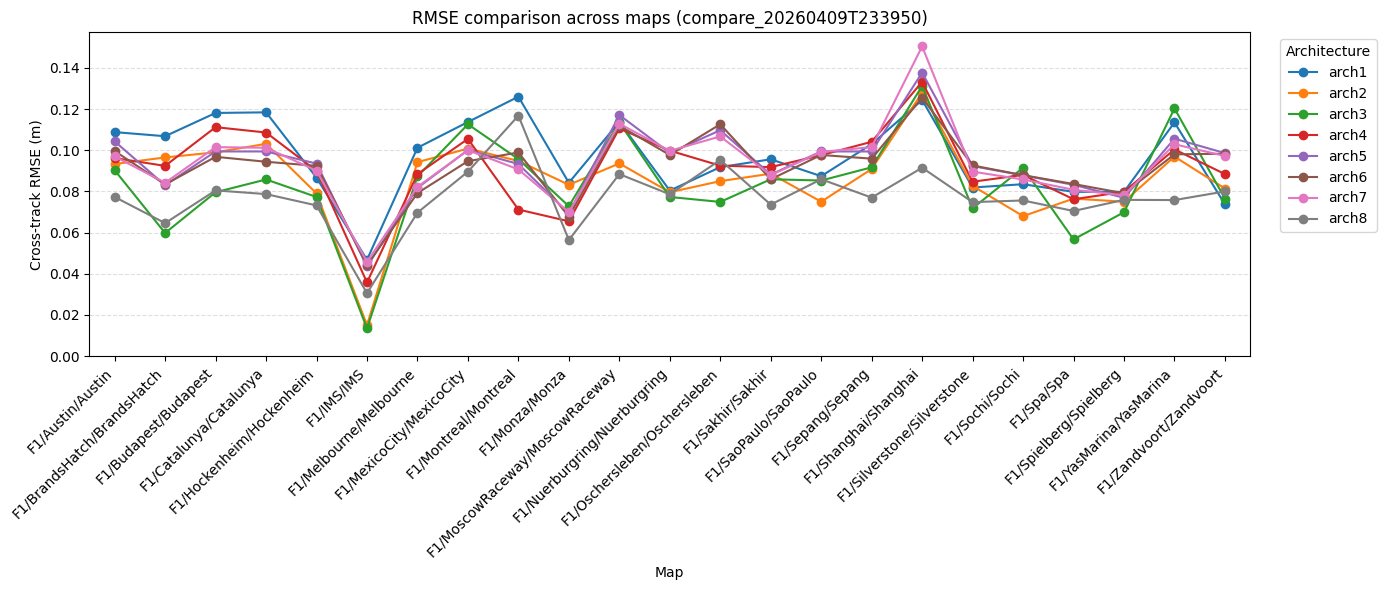

In [10]:
maps = list(pivot.columns)
x_positions = range(len(maps))
fig, ax = plt.subplots(figsize=(14, 6))
for arch, row in pivot.iterrows():
    ax.plot(x_positions, row.values, marker="o", linewidth=1.5, label=arch)
ax.set_xticks(list(x_positions))
ax.set_xticklabels(maps, rotation=45, ha="right")
ax.set_xlim(-0.5, len(maps) - 0.5)
ax.set_ylabel("Cross-track RMSE (m)")
ax.set_xlabel("Map")
ax.set_title(f"RMSE comparison across maps ({RUN_DIR.name})")
ax.set_ylim(bottom=0)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Architecture", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
